# Évaluation des données générées

Ici on compare les données du DDPM et du VAE, sur California puis sur MAGIC. Cinq questions :

1. Est-ce que les données générées ressemblent aux vraies ?
2. Est-ce qu'un modèle entraîné dessus marche sur des vraies données ?
3. Est-ce qu'en ajouter à un peu de vraies données aide ?
4. Est-ce que le générateur recopie le train ?
5. Est-ce que la ressemblance suffit pour savoir si les données sont utiles ?

Le test est utilisé ici pour la première fois. Les modèles d'évaluation sont ceux du notebook 02, avec les mêmes réglages. La partie 5 utilise la validation pour ne pas rouvrir le test.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from scipy.stats import wasserstein_distance, spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.preprocessing import QuantileTransformer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import r2_score, roc_auc_score

## 0. Données

Les vraies données (train, val, test) et les fichiers générés dans les notebooks 03 et 04. Chaque fichier généré a autant de lignes que le train. Pour California on garde les deux versions du DDPM (t/T et sinusoïdale).

In [2]:
cal_train = pd.read_csv("data/processed/california_train.csv")
cal_val = pd.read_csv("data/processed/california_val.csv")
cal_test = pd.read_csv("data/processed/california_test.csv")
cal_ddpm = pd.read_csv("data/synthetic/california_ddpm_naif.csv")
cal_sinus = pd.read_csv("data/synthetic/california_ddpm_sinus.csv")
cal_vae = pd.read_csv("data/synthetic/california_vae.csv")

magic_train = pd.read_csv("data/processed/magic_train.csv")
magic_val = pd.read_csv("data/processed/magic_val.csv")
magic_test = pd.read_csv("data/processed/magic_test.csv")
magic_ddpm = pd.read_csv("data/synthetic/magic_ddpm.csv")
magic_vae = pd.read_csv("data/synthetic/magic_vae.csv")

print(cal_train.shape, cal_test.shape, cal_ddpm.shape, cal_sinus.shape, cal_vae.shape)
print(magic_train.shape, magic_test.shape, magic_ddpm.shape, magic_vae.shape)

(14447, 9) (3097, 9) (14447, 9) (14447, 9) (14447, 9)
(13233, 11) (2836, 11) (13233, 11) (13233, 11)


## 1. Ressemblance

**Distance de Wasserstein.** On compare une colonne du train et la même colonne du synthétique. On peut voir chaque histogramme comme un tas de sable : la distance de Wasserstein, c'est le travail minimal pour transformer un tas en l'autre (quantité de sable déplacée × distance). En 1D c'est l'aire entre les deux fonctions de répartition. On la divise par l'écart-type de la colonne pour pouvoir faire la moyenne sur toutes les colonnes.

**Écart des corrélations.** Wasserstein regarde les colonnes une par une, il ne voit pas les liens entre elles. Pour ça on calcule la matrice des corrélations de Spearman (corrélation sur les rangs) du train et du synthétique, et on regarde l'écart entre les deux : le plus grand écart et l'écart moyen.

Le test réel sert de référence : c'est ce que donnerait un générateur parfait. Il a moins de lignes que le synthétique, donc ses distances sont un peu plus grandes qu'elles ne devraient.

In [3]:
def ressemblance(train, df):
    cols = train.columns
    w = [wasserstein_distance(train[c], df[c]) / train[c].std() for c in cols]
    ecart = (train.corr("spearman") - df[cols].corr("spearman")).abs().to_numpy()
    hors_diag = ecart[~np.eye(len(cols), dtype=bool)]
    return np.mean(w), hors_diag.max(), hors_diag.mean(), w


lignes = []
w_colonnes = {}
for nom, df in [("test réel", cal_test), ("DDPM t/T", cal_ddpm), ("DDPM sinus", cal_sinus), ("VAE", cal_vae)]:
    w, cmax, cmoy, w_cols = ressemblance(cal_train, df)
    print(f"California {nom:10s} Wasserstein {w:.3f}   corr max {cmax:.3f}   corr moy {cmoy:.3f}")
    lignes.append(["california", nom, w, cmax, cmoy])
    w_colonnes[nom] = w_cols

pd.DataFrame(w_colonnes, index=cal_train.columns).round(3)

California test réel  Wasserstein 0.020   corr max 0.036   corr moy 0.015
California DDPM t/T   Wasserstein 0.081   corr max 0.094   corr moy 0.026
California DDPM sinus Wasserstein 0.046   corr max 0.073   corr moy 0.026
California VAE        Wasserstein 0.130   corr max 0.303   corr moy 0.090


,test réel,DDPM t/T,DDPM sinus,VAE
MedInc,0.019,0.157,0.016,0.119
HouseAge,0.023,0.032,0.126,0.214
AveRooms,0.033,0.112,0.036,0.132
AveBedrms,0.033,0.032,0.030,0.107
Population,0.019,0.102,0.057,0.243
AveOccup,0.017,0.030,0.051,0.043
Latitude,0.015,0.025,0.033,0.084
Longitude,0.013,0.058,0.032,0.068
target,0.007,0.181,0.029,0.157


In [4]:
w_colonnes = {}
for nom, df in [("test réel", magic_test), ("DDPM", magic_ddpm), ("VAE", magic_vae)]:
    w, cmax, cmoy, w_cols = ressemblance(magic_train, df)
    print(f"MAGIC {nom:10s} Wasserstein {w:.3f}   corr max {cmax:.3f}   corr moy {cmoy:.3f}")
    lignes.append(["magic", nom, w, cmax, cmoy])
    w_colonnes[nom] = w_cols

res_ressemblance = pd.DataFrame(lignes, columns=["jeu", "source", "wasserstein", "corr_max", "corr_moy"])
pd.DataFrame(w_colonnes, index=magic_train.columns).round(3)

MAGIC test réel  Wasserstein 0.034   corr max 0.035   corr moy 0.012
MAGIC DDPM       Wasserstein 0.035   corr max 0.072   corr moy 0.020
MAGIC VAE        Wasserstein 0.137   corr max 0.248   corr moy 0.086


,test réel,DDPM,VAE
fLength,0.032,0.035,0.095
fWidth,0.043,0.038,0.121
fSize,0.046,0.029,0.068
fConc,0.057,0.025,0.038
fConc1,0.049,0.008,0.048
fAsym,0.023,0.091,0.253
fM3Long,0.038,0.051,0.239
fM3Trans,0.030,0.048,0.244
fAlpha,0.026,0.020,0.150
fDist,0.031,0.031,0.245


## 2. Utilité : entraîner sur du synthétique, tester sur du réel (TSTR)

La question pratique : si on n'avait que les données générées, est-ce qu'on pourrait apprendre un bon modèle ? On entraîne les deux modèles du notebook 02 sur chaque source, puis on les teste sur le vrai test. La ligne « réel » (entraîné sur le vrai train) est le score à viser.

- GBM : `HistGradientBoosting` avec les réglages par défaut.
- MLP : 2 couches de 64, Adam, batch 256, 100 epochs, entrées passées par une transformation par quantiles.

Score : R² pour California (1 = parfait), AUC pour MAGIC (0,5 = au hasard, 1 = parfait). On fait 3 graines et on regarde la moyenne et l'écart-type.

In [5]:
# même réseau et mêmes réglages que dans 02_baseline_model.ipynb
EPOCHS, BATCH, LR = 100, 256, 1e-3

def fit_mlp(X, y, task, seed):
    torch.manual_seed(seed)
    qt = QuantileTransformer(output_distribution="normal").fit(X)
    X_t = torch.tensor(qt.transform(X), dtype=torch.float32)
    y_t = torch.tensor(y.to_numpy(), dtype=torch.float32)

    model = nn.Sequential(
        nn.Linear(X_t.shape[1], 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 1),
    )
    loss_fn = nn.MSELoss() if task == "regression" else nn.BCEWithLogitsLoss()
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    for epoch in range(EPOCHS):
        perm = torch.randperm(len(X_t))
        for i in range(0, len(X_t), BATCH):
            idx = perm[i:i + BATCH]
            loss = loss_fn(model(X_t[idx]).squeeze(1), y_t[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
    return model, qt


def predict_mlp(model, qt, X):
    X_t = torch.tensor(qt.transform(X), dtype=torch.float32)
    with torch.no_grad():
        return model(X_t).squeeze(1).numpy()


def score_gbm(train, test, task, seed):
    X, y = train.drop(columns="target"), train["target"]
    if task == "regression":
        gbm = HistGradientBoostingRegressor(random_state=seed).fit(X, y)
        return r2_score(test["target"], gbm.predict(test.drop(columns="target")))
    gbm = HistGradientBoostingClassifier(random_state=seed).fit(X, y)
    return roc_auc_score(test["target"], gbm.predict_proba(test.drop(columns="target"))[:, 1])


def score_mlp(train, test, task, seed):
    mlp, qt = fit_mlp(train.drop(columns="target"), train["target"], task, seed)
    pred = predict_mlp(mlp, qt, test.drop(columns="target"))
    if task == "regression":
        return r2_score(test["target"], pred)
    return roc_auc_score(test["target"], pred)

In [6]:
lignes = []
for nom, df in [("réel", cal_train), ("DDPM t/T", cal_ddpm), ("DDPM sinus", cal_sinus), ("VAE", cal_vae)]:
    gbm = [score_gbm(df, cal_test, "regression", seed) for seed in [0, 1, 2]]
    mlp = [score_mlp(df, cal_test, "regression", seed) for seed in [0, 1, 2]]
    print(f"California {nom:10s} GBM {np.mean(gbm):.3f} ± {np.std(gbm):.3f}   MLP {np.mean(mlp):.3f} ± {np.std(mlp):.3f}")
    lignes.append(["california", nom, np.mean(gbm), np.std(gbm), np.mean(mlp), np.std(mlp)])

California réel       GBM 0.826 ± 0.003   MLP 0.787 ± 0.002
California DDPM t/T   GBM 0.747 ± 0.001   MLP 0.756 ± 0.002
California DDPM sinus GBM 0.736 ± 0.001   MLP 0.745 ± 0.003
California VAE        GBM 0.670 ± 0.002   MLP 0.626 ± 0.020


In [7]:
for nom, df in [("réel", magic_train), ("DDPM", magic_ddpm), ("VAE", magic_vae)]:
    gbm = [score_gbm(df, magic_test, "classification", seed) for seed in [0, 1, 2]]
    mlp = [score_mlp(df, magic_test, "classification", seed) for seed in [0, 1, 2]]
    print(f"MAGIC {nom:10s} GBM {np.mean(gbm):.3f} ± {np.std(gbm):.3f}   MLP {np.mean(mlp):.3f} ± {np.std(mlp):.3f}")
    lignes.append(["magic", nom, np.mean(gbm), np.std(gbm), np.mean(mlp), np.std(mlp)])

res_tstr = pd.DataFrame(lignes, columns=["jeu", "source", "gbm", "gbm_std", "mlp", "mlp_std"])

MAGIC réel       GBM 0.936 ± 0.000   MLP 0.940 ± 0.000
MAGIC DDPM       GBM 0.929 ± 0.000   MLP 0.928 ± 0.002
MAGIC VAE        GBM 0.884 ± 0.001   MLP 0.836 ± 0.004


## 3. Courbe de mélange

Le TSTR teste le cas « que du synthétique ». Ici on regarde un cas plus réaliste : on n'a qu'une partie des vraies données (25, 50, 75 ou 100 % du train, comme dans le notebook 02) et on se demande si ajouter les données générées aide.

Pour chaque part de réel et chaque graine, on entraîne le GBM sur le réel seul, puis sur le réel + tout le synthétique d'un générateur. Si « réel + synthétique » est au-dessus de « réel seul », le synthétique apporte quelque chose. On ne fait que le GBM ici, pour que ça reste rapide.

California
                    0.25   0.50   0.75   1.00
réel seul          0.803  0.818  0.825  0.827
réel + DDPM t/T    0.774  0.785  0.793  0.802
réel + DDPM sinus  0.762  0.781  0.793  0.799
réel + VAE         0.765  0.785  0.796  0.803
MAGIC
              0.25   0.50   0.75   1.00
réel seul    0.923  0.933  0.935  0.937
réel + DDPM  0.935  0.936  0.936  0.937
réel + VAE   0.924  0.931  0.935  0.937


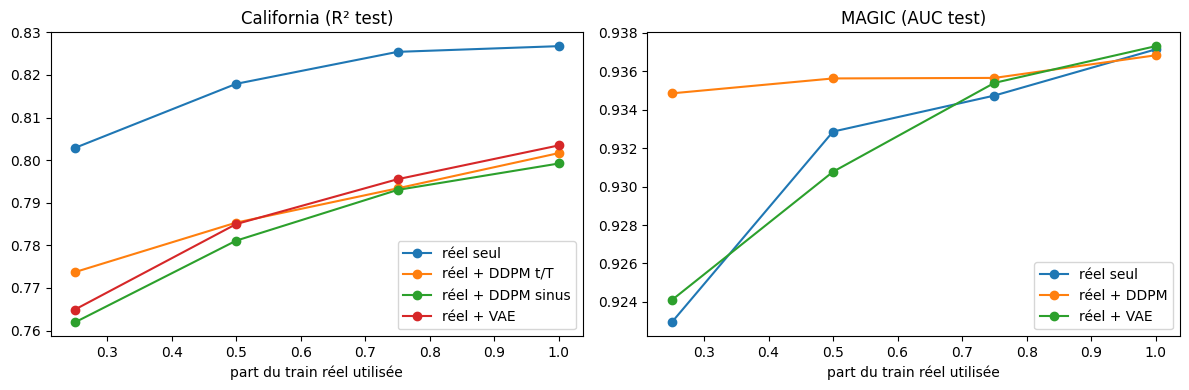

In [8]:
parts = [0.25, 0.5, 0.75, 1.0]

def courbe_melange(train, test, task, synth):
    courbes = {"réel seul": []}
    for nom, _ in synth:
        courbes["réel + " + nom] = []

    for frac in parts:
        scores = {k: [] for k in courbes}
        for seed in [0, 1, 2]:
            sub = train.sample(frac=frac, random_state=seed)
            scores["réel seul"].append(score_gbm(sub, test, task, seed))
            for nom, df in synth:
                scores["réel + " + nom].append(score_gbm(pd.concat([sub, df]), test, task, seed))
        for k in courbes:
            courbes[k].append(np.mean(scores[k]))
    return courbes


melange_cal = courbe_melange(cal_train, cal_test, "regression", [("DDPM t/T", cal_ddpm), ("DDPM sinus", cal_sinus), ("VAE", cal_vae)])
melange_magic = courbe_melange(magic_train, magic_test, "classification", [("DDPM", magic_ddpm), ("VAE", magic_vae)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, titre, courbes in [(axes[0], "California (R² test)", melange_cal), (axes[1], "MAGIC (AUC test)", melange_magic)]:
    for nom, scores in courbes.items():
        ax.plot(parts, scores, marker="o", label=nom)
    ax.set_title(titre)
    ax.set_xlabel("part du train réel utilisée")
    ax.legend()
fig.tight_layout()
fig.savefig("figures/eval_courbe_melange.png", dpi=150, bbox_inches="tight")

print("California", pd.DataFrame(melange_cal, index=parts).T.round(3), sep="\n")
print("MAGIC", pd.DataFrame(melange_magic, index=parts).T.round(3), sep="\n")

## 4. Mémorisation : distance au plus proche voisin du train (DCR)

Un générateur qui recopierait le train aurait de très bons scores partout sans rien avoir appris. Pour vérifier, on calcule pour chaque ligne générée la distance à la ligne du train la plus proche. Les distances sont calculées après une transformation par quantiles, pour que toutes les colonnes pèsent pareil.

On compare au test réel : de vraies lignes que le générateur n'a jamais vues. Si les lignes générées sont beaucoup plus proches du train que le test, il y a copie. Attention, une médiane plus petite ne veut pas forcément dire copie : un générateur qui lisse met plus de points dans les zones denses, donc près de vraies lignes. Ce qu'on regarde surtout, c'est le 5e percentile et le nombre de quasi-copies (distance < 0,05).

In [9]:
def dcr(train, df):
    qt = QuantileTransformer(output_distribution="normal", random_state=0).fit(train)
    voisins = NearestNeighbors(n_neighbors=1).fit(qt.transform(train))
    dist = voisins.kneighbors(qt.transform(df[train.columns]))[0][:, 0]
    return np.median(dist), np.percentile(dist, 5), (dist < 0.05).sum()


lignes = []
for jeu, train, sources in [("california", cal_train, [("test réel", cal_test), ("DDPM t/T", cal_ddpm), ("DDPM sinus", cal_sinus), ("VAE", cal_vae)]),
                            ("magic", magic_train, [("test réel", magic_test), ("DDPM", magic_ddpm), ("VAE", magic_vae)])]:
    for nom, df in sources:
        med, p5, copies = dcr(train, df)
        print(f"{jeu:10s} {nom:10s} médiane {med:.3f}   5e percentile {p5:.3f}   quasi-copies {copies}")
        lignes.append([jeu, nom, med, p5, copies])

res_dcr = pd.DataFrame(lignes, columns=["jeu", "source", "mediane", "p5", "quasi_copies"])

california test réel  médiane 0.749   5e percentile 0.454   quasi-copies 0
california DDPM t/T   médiane 0.826   5e percentile 0.519   quasi-copies 0
california DDPM sinus médiane 0.867   5e percentile 0.542   quasi-copies 0
california VAE        médiane 0.659   5e percentile 0.443   quasi-copies 0
magic      test réel  médiane 0.705   5e percentile 0.404   quasi-copies 0
magic      DDPM       médiane 0.756   5e percentile 0.483   quasi-copies 0
magic      VAE        médiane 0.590   5e percentile 0.407   quasi-copies 0


## 5. Ressemblance et utilité au fil de l'entraînement

C'est la question centrale du projet : est-ce que les mesures de ressemblance disent si les données seront utiles ? Si oui, on pourrait choisir un générateur sans entraîner de modèle derrière.

Avec seulement 2 ou 3 générateurs on ne peut pas répondre. Mais on a sauvegardé le DDPM et le VAE toutes les 20 epochs, et chaque checkpoint est un générateur plus ou moins bon. Pour chacun :
1. on génère 5 000 lignes ;
2. ressemblance : Wasserstein et plus grand écart des corrélations, par rapport au train ;
3. utilité : un GBM entraîné sur ces lignes, évalué sur la validation.

Ensuite on calcule la corrélation de Spearman entre ressemblance et utilité. On classe les checkpoints selon la ressemblance, puis selon l'utilité, et on regarde si les deux classements sont dans le même ordre. On attend une valeur négative (petite distance = grande utilité) : vers -1 la ressemblance classe bien les générateurs, vers 0 elle ne dit rien.

Pour recharger les checkpoints, il faut redéfinir les mêmes modèles que dans 03 et 04, et refaire la même transformation par quantiles (même bruit, même graine) pour revenir aux vraies unités.

In [10]:
T = 1000
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)


class Debruiteur(nn.Module):
    def __init__(self, d, d_cond=0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1 + d_cond, 256), nn.SiLU(),   # x_t + t (+ classe pour MAGIC)
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, d)
        )

    def forward(self, x_t, t, y=None):
        h = [x_t, (t.float() / T).unsqueeze(1)]
        if y is not None:
            h.append(y.unsqueeze(1))
        return self.net(torch.cat(h, dim=1))


class Encodeur(nn.Module):
    def __init__(self, d, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU()
        )
        self.mu = nn.Linear(256, latent_dim)
        self.log_var = nn.Linear(256, latent_dim)


class Decodeur(nn.Module):
    def __init__(self, d, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, d)
        )


class VAE(nn.Module):
    def __init__(self, d, latent_dim, d_cond=0):
        super().__init__()
        self.encodeur = Encodeur(d + d_cond, latent_dim)
        self.decodeur = Decodeur(d, latent_dim + d_cond)


def generer_ddpm(model, n, d, y=None):
    with torch.no_grad():
        x_t = torch.randn(n, d)
        for t in range(T - 1, -1, -1):
            t_batch = torch.full((n,), t, dtype=torch.long)
            eps_pred = model(x_t, t_batch, y)
            z = torch.randn(n, d) if t > 0 else 0
            x_t = 1 / torch.sqrt(alphas[t]) * (x_t - (1 - alphas[t]) / torch.sqrt(1 - alphas_cumprod[t]) * eps_pred) + torch.sqrt(betas[t]) * z
    return x_t


def generer_vae(model, n, latent_dim, y=None):
    with torch.no_grad():
        z = torch.randn(n, latent_dim)
        if y is not None:
            z = torch.cat([z, y.unsqueeze(1)], dim=1)
        return model.decodeur.net(z)

In [11]:
# même transformation par quantiles que dans 03 et 04 (même bruit, même graine)
rng = np.random.default_rng(0)
bruit = 1e-6 * cal_train.std().to_numpy() * rng.uniform(-1, 1, cal_train.shape)
qt_cal = QuantileTransformer(output_distribution="normal", n_quantiles=1000, subsample=None, random_state=0).fit(cal_train + bruit)

cols_m = magic_train.columns.drop("target")
rng = np.random.default_rng(0)
bruit_m = 1e-6 * magic_train[cols_m].std().to_numpy() * rng.uniform(-1, 1, magic_train[cols_m].shape)
qt_m = QuantileTransformer(output_distribution="normal", n_quantiles=1000, subsample=None, random_state=0).fit(magic_train[cols_m] + bruit_m)

In [12]:
epochs = list(range(0, 200, 20)) + [199]
n = 5000

lignes = []
for epoch in epochs:
    # California : on génère toutes les colonnes d'un coup (variables + prix)
    for modele, fichier in [("DDPM", "ddpm_naif"), ("VAE", "vae_california")]:
        poids = torch.load(f"checkpoints/{fichier}_ep{epoch}.pt")
        torch.manual_seed(0)
        if modele == "DDPM":
            net = Debruiteur(9)
            net.load_state_dict(poids)
            x = generer_ddpm(net, n, 9)
        else:
            latent = poids["encodeur.mu.weight"].shape[0]   # taille du latent lue dans le checkpoint
            net = VAE(9, latent)
            net.load_state_dict(poids)
            x = generer_vae(net, n, latent)
        df = pd.DataFrame(qt_cal.inverse_transform(pd.DataFrame(x.numpy(), columns=cal_train.columns)), columns=cal_train.columns)
        df["HouseAge"] = df["HouseAge"].round()
        w, cmax, _, _ = ressemblance(cal_train, df)
        lignes.append(["california", modele, epoch, w, cmax, score_gbm(df, cal_val, "regression", 0)])

    # MAGIC : classe tirée au hasard dans le train, puis variables sachant la classe
    for modele, fichier in [("DDPM", "ddpm_magic"), ("VAE", "vae_magic")]:
        poids = torch.load(f"checkpoints/{fichier}_ep{epoch}.pt")
        torch.manual_seed(0)
        y = torch.tensor(magic_train["target"].values).float()[torch.randint(0, len(magic_train), (n,))]
        if modele == "DDPM":
            net = Debruiteur(10, d_cond=1)
            net.load_state_dict(poids)
            x = generer_ddpm(net, n, 10, y)
        else:
            latent = poids["encodeur.mu.weight"].shape[0]
            net = VAE(10, latent, d_cond=1)
            net.load_state_dict(poids)
            x = generer_vae(net, n, latent, y)
        df = pd.DataFrame(qt_m.inverse_transform(pd.DataFrame(x.numpy(), columns=cols_m)), columns=cols_m)
        df["target"] = y.int().numpy()
        w, cmax, _, _ = ressemblance(magic_train, df)
        lignes.append(["magic", modele, epoch, w, cmax, score_gbm(df, magic_val, "classification", 0)])
    print("epoch", epoch, "fait")

res_ckpt = pd.DataFrame(lignes, columns=["jeu", "modele", "epoch", "wasserstein", "corr_max", "utilite"])

epoch 0 fait
epoch 20 fait
epoch 40 fait
epoch 60 fait
epoch 80 fait
epoch 100 fait
epoch 120 fait
epoch 140 fait
epoch 160 fait
epoch 180 fait
epoch 199 fait


california wasserstein  rho tous -0.79   DDPM seul -0.23   VAE seul -0.05
california corr_max     rho tous -0.74   DDPM seul -0.47   VAE seul +0.41
magic      wasserstein  rho tous -0.81   DDPM seul -0.11   VAE seul -0.37
magic      corr_max     rho tous -0.87   DDPM seul -0.36   VAE seul -0.61


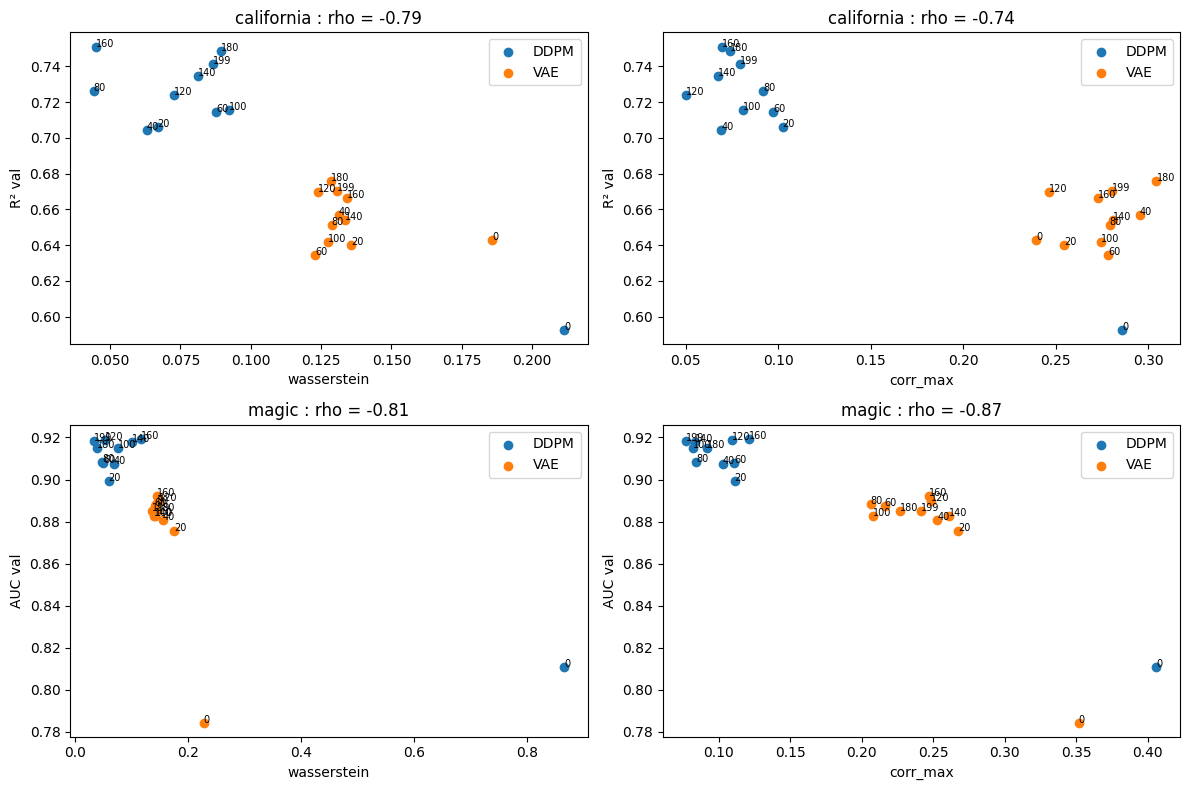

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, jeu in enumerate(["california", "magic"]):
    r = res_ckpt[res_ckpt["jeu"] == jeu]
    for k, mesure in enumerate(["wasserstein", "corr_max"]):
        ax = axes[i, k]
        for modele in ["DDPM", "VAE"]:
            rm = r[r["modele"] == modele]
            ax.scatter(rm[mesure], rm["utilite"], label=modele)
            for _, ligne in rm.iterrows():
                ax.annotate(int(ligne["epoch"]), (ligne[mesure], ligne["utilite"]), fontsize=7)
        ax.set_title(f"{jeu} : rho = {spearmanr(r[mesure], r['utilite'])[0]:.2f}")
        ax.set_xlabel(mesure)
        ax.set_ylabel("R² val" if jeu == "california" else "AUC val")
        ax.legend()
fig.tight_layout()
fig.savefig("figures/eval_ressemblance_vs_utilite.png", dpi=150, bbox_inches="tight")

# rho sur tous les checkpoints, puis pour chaque modèle seul
for jeu in ["california", "magic"]:
    r = res_ckpt[res_ckpt["jeu"] == jeu]
    for mesure in ["wasserstein", "corr_max"]:
        tous = spearmanr(r[mesure], r["utilite"])[0]
        ddpm = spearmanr(r[r["modele"] == "DDPM"][mesure], r[r["modele"] == "DDPM"]["utilite"])[0]
        vae = spearmanr(r[r["modele"] == "VAE"][mesure], r[r["modele"] == "VAE"]["utilite"])[0]
        print(f"{jeu:10s} {mesure:12s} rho tous {tous:+.2f}   DDPM seul {ddpm:+.2f}   VAE seul {vae:+.2f}")

## 6. Sauvegarde des résultats

In [14]:
os.makedirs("results", exist_ok=True)
res_ressemblance.to_csv("results/eval_ressemblance_test.csv", index=False)
res_tstr.to_csv("results/eval_tstr_test.csv", index=False)
pd.concat({"california": pd.DataFrame(melange_cal, index=parts).T, "magic": pd.DataFrame(melange_magic, index=parts).T}).to_csv("results/eval_melange_test.csv")
res_dcr.to_csv("results/eval_dcr_test.csv", index=False)
res_ckpt.to_csv("results/eval_checkpoints_val.csv", index=False)